In [ ]:
!pip install pylatexenc qiskit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.2 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=a1ace2613cd58a840126c24ede17f6d452e379541df8f132f3a5fe650a0b5631
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter, Instruction, Gate
from qiskit.circuit.library import *
import numpy as np
import matplotlib.pyplot as plt


# Standard Directives in Qiskit

---

# Definition

Directives are special circuit instructions that:

- control circuit behavior
- guide transpilation
- manage execution flow

They are NOT normal quantum gates.

---

# Important Difference

## Quantum Gates

Examples:

- X
- H
- CX

These:

- are unitary
- change quantum states
- perform computations

---

## Directives

Examples:

- barrier
- measure
- reset
- delay

These:

- control execution
- manage hardware/compiler behavior
- are often non-unitary

---

# Common Standard Directives

| Directive | Purpose |
|---|---|
| barrier | Prevent optimization/reordering |
| measure | Measure qubit |
| reset | Reset qubit to \(|0\rangle\) |
| delay | Wait operation |
| store | Store classical data |
| box | Structural grouping |

---

# Barrier

Prevents the transpiler from moving gates across it.

```python
qc.barrier()
```

Visual idea:

```text
---H---|---X---
```

The barrier acts like a wall.

---

# Important

Barrier does NOT change the quantum state.

It only affects transpilation and optimization.

---

# Measure

Measures qubit into a classical bit.

```python
qc.measure(0,0)
```

Example:

$$
\alpha|0\rangle+\beta|1\rangle
$$

collapses into either:

$$
|0\rangle
$$

or

$$
|1\rangle
$$

---

# Important

Measurement is:

- non-unitary
- irreversible

---

# Reset

Resets a qubit back to:

$$
|0\rangle
$$

```python
qc.reset(0)
```

Often implemented internally using:

1. measurement
2. conditional X gate

---

# Delay

Introduces waiting time.

```python
qc.delay(100,0,unit='ns')
```

Means:

- wait 100 nanoseconds

---

# Purpose of Delay

Used for:

- pulse scheduling
- timing control
- synchronization
- decoherence experiments

---

# Store

Stores classical data in dynamic circuits.

Less commonly used in beginner circuits.

---

# Box

Groups operations structurally.

Useful for organizing complex circuits.

---

# Example Circuit

```python
qc.h(0)

qc.barrier()

qc.cx(0,1)

qc.measure([0,1],[0,1])
```

Meaning:

1. create superposition
2. prevent optimization crossing barrier
3. entangle qubits
4. measure qubits

---

# Core Idea

Directives help control:

- transpilation
- timing
- measurement
- execution flow

instead of acting as standard reversible quantum gates.

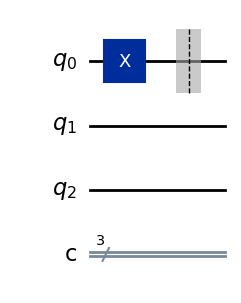

In [ ]:
# Directive
b = Barrier(1)
qc =  QuantumCircuit(3, 3)
qc.compose(XGate(), qubits=[0]).compose(b).draw('mpl')

Measure

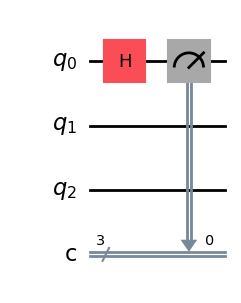

In [ ]:
# Operation -Measure
qc.compose(HGate()).compose(Measure()).draw('mpl')

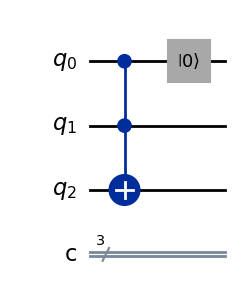

In [ ]:
# Operation- Reset
qc.compose(CCXGate()).compose(Reset()).draw('mpl')

Generalized Gates



*   Extends the standard gates
*   contains variadic gates "number of qubits depends on the input"
*   It is recommended to use Gates that derive Instrcution or Gate instead of QuantumCircuit , as the former allows the compiler to reason about it on an abstract level , while the latter is eagerly constructed







In [ ]:
diagonal = DiagonalGate([1, 1])
print(diagonal.num_qubits)

1


In [ ]:
diagonal = DiagonalGate([1, 1, 1, 1, 1, 1, 1, 1])
print(diagonal.num_qubits)

# inputs should be in power of 2

3


# Gate and Instruction Representations in Qiskit

These are advanced generalized gate representations used for:

- circuit synthesis
- decomposition
- quantum compilation
- simulation
- variational algorithms

---

# DiagonalGate

## Generic Diagonal Quantum Gate

Represents gates with non-zero elements only on the diagonal.

General form:

$$
D=
\begin{bmatrix}
d_1 & 0 & 0 \\
0 & d_2 & 0 \\
0 & 0 & d_3
\end{bmatrix}
$$

Useful for:

- phase operations
- Hamiltonian simulation
- optimization

```python
DiagonalGate([...])
```

---

# PermutationGate

## Qubit Permutation Gate

Permutes computational basis states.

Example:

$$
|001\rangle \rightarrow |100\rangle
$$

Useful for:

- qubit routing
- wire rearrangement
- transpilation

```python
PermutationGate([...])
```

---

# MCMTGate

## Multi-Control Multi-Target Gate

Generalized controlled gate.

Applies a controlled operation to multiple target qubits.

Example:

```text
many controls → many targets
```

```python
MCMTGate(gate, num_ctrl, num_target)
```

---

# MCPhaseGate

## Multi-Controlled Phase Gate

Applies phase shift only if all controls are 1.

General form:

$$
e^{i\phi}
$$

controlled by multiple qubits.

```python
MCPhaseGate(theta, num_ctrl_qubits)
```

---

# MCXGate

## Multi-Controlled X Gate

Generalized controlled-X gate.

Examples:

- CX
- CCX
- C3X

are all special cases.

```python
MCXGate(num_ctrl_qubits)
```

---

# MSGate

## Mølmer–Sørensen Gate

Entangling interaction gate used in trapped-ion quantum computers.

Interaction form:

$$
XX + YY
$$

Creates entanglement between qubits.

```python
MSGate(theta, num_qubits)
```

---

# RVGate

## Arbitrary Rotation Gate

Rotation around arbitrary vector:

$$
\vec{v}
$$

Magnitude:

$$
||v||
$$

determines rotation angle.

General rotation:

$$
R_v(\theta)
$$

```python
RVGate(vx, vy, vz)
```

---

# PauliGate

## Multi-Qubit Pauli Gate

Represents arbitrary tensor products of Pauli operators.

Examples:

$$
X \otimes Y \otimes Z
$$

$$
IZZ
$$

```python
PauliGate("XYZ")
```

---

# LinearFunction

## Linear Reversible Circuit

Represents reversible linear Boolean functions.

Based on:

- XOR operations
- binary linear algebra

Useful in:

- reversible computing
- arithmetic circuits

```python
LinearFunction(matrix)
```

---

# Isometry

## Arbitrary Isometry Decomposition

Represents mappings between quantum spaces.

Maps:

$$
m \text{ qubits}
\rightarrow
n \text{ qubits}
$$

Used in:

- state preparation
- quantum synthesis

```python
Isometry(matrix, ...)
```

---

# UnitaryGate

## Arbitrary Unitary Matrix Gate

Represents any custom unitary matrix.

Condition:

$$
U^\dagger U = I
$$

Example:

```python
UnitaryGate(matrix)
```

Allows user-defined quantum operations.

---

# UCGate

## Uniformly Controlled Gate

Also called multiplexed gate.

Different operations applied depending on control states.

Useful in:

- quantum multiplexers
- state preparation

```python
UCGate(...)
```

---

# UCPauliRotGate

## Uniformly Controlled Pauli Rotations

General framework for controlled Pauli rotations.

Supports:

- X rotations
- Y rotations
- Z rotations

```python
UCPauliRotGate(...)
```

---

# UCRXGate

## Uniformly Controlled RX Rotations

Applies different RX rotations based on control qubits.

$$
R_X(\theta)
$$

```python
UCRXGate(...)
```

---

# UCRYGate

## Uniformly Controlled RY Rotations

Applies different RY rotations conditionally.

$$
R_Y(\theta)
$$

```python
UCRYGate(...)
```

---

# UCRZGate

## Uniformly Controlled RZ Rotations

Applies different RZ rotations conditionally.

$$
R_Z(\theta)
$$

```python
UCRZGate(...)
```

---

# Important Concept

These gates are usually:

- generalized
- parameterized
- synthesis-oriented
- compiler-level abstractions

rather than simple beginner quantum gates.

---

# Summary Table

| Gate | Purpose |
|---|---|
| DiagonalGate | Generic diagonal matrix gate |
| PermutationGate | Rearranges basis states |
| MCMTGate | Multi-control multi-target gate |
| MCPhaseGate | Multi-controlled phase |
| MCXGate | Generalized controlled-X |
| MSGate | Entangling ion-trap gate |
| RVGate | Arbitrary-axis rotation |
| PauliGate | Multi-qubit Pauli operator |
| LinearFunction | Reversible linear circuit |
| Isometry | Arbitrary state mapping |
| UnitaryGate | Custom unitary matrix |
| UCGate | Multiplexed controlled gate |
| UCRX/Y/Z | Uniformly controlled rotations |

---

# Core Idea

These representations provide flexible ways to define:

- arbitrary quantum operations
- generalized rotations
- synthesis structures
- advanced compiler transformations
- hardware-efficient decompositions

# QuantumCircuit Representations in Qiskit

These are higher-level circuit implementations used for:

- circuit synthesis
- decomposition
- optimization
- hardware-efficient execution

They are usually implemented as complete quantum circuits rather than single gates.

---

# Diagonal

## Circuit for Diagonal Transformations

Implements a diagonal unitary matrix.

General form:

$$
D=
\begin{bmatrix}
d_1 & 0 & 0 \\
0 & d_2 & 0 \\
0 & 0 & d_3
\end{bmatrix}
$$

Used for:

- phase operations
- Hamiltonian simulation
- quantum optimization

```python
Diagonal([...])
```

---

# MCMT

## Multi-Control Multi-Target Circuit

Generalized controlled operation.

Applies a controlled gate to multiple targets.

Structure:

```text
many controls → many targets
```

```python
MCMT(gate, num_ctrl, num_target)
```

---

# MCMTVChain

## MCMT Using V-Chain Implementation

Implements MCMT using:

- CCX gates
- V-chain decomposition

Optimized for:

- lower ancilla usage
- efficient decomposition

```python
MCMTVChain(...)
```

---

# MCXGrayCode

## Multi-Controlled X Using Gray Code

Implements MCX gate using Gray code sequence.

Gray code changes only one bit at a time.

Useful for:

- structured decomposition
- systematic state transitions

```python
MCXGrayCode(num_ctrl_qubits)
```

---

# MCXRecursive

## Recursive MCX Implementation

Builds MCX recursively from smaller controlled gates.

Advantages:

- scalable
- lower decomposition complexity

```python
MCXRecursive(num_ctrl_qubits)
```

---

# MCXVChain

## V-Chain MCX Implementation

Uses a chain of:

$$
CX
$$

and ancilla qubits.

Optimized for:

- hardware execution
- reduced depth

```python
MCXVChain(num_ctrl_qubits)
```

---

# Permutation

## Qubit Permutation Circuit

Permutes qubit ordering.

Example:

$$
|001\rangle \rightarrow |100\rangle
$$

Used for:

- routing
- transpilation
- qubit mapping

```python
Permutation([...])
```

---

# GMS

## Global Mølmer–Sørensen Gate

Global entangling gate used in trapped-ion quantum systems.

Interaction form:

$$
XX + YY
$$

Creates entanglement across many qubits simultaneously.

```python
GMS(num_qubits, theta)
```

---

# GR

## Global Rotation Gate

Applies the same arbitrary rotation to all qubits.

General form:

$$
R(\theta,\phi)
$$

Applied globally.

```python
GR(num_qubits, theta, phi)
```

---

# GRX

## Global RX Gate

Applies:

$$
R_X(\theta)
$$

to every qubit simultaneously.

```python
GRX(num_qubits, theta)
```

Equivalent idea:

```python
for q in qubits:
    RX(theta)
```

---

# GRY

## Global RY Gate

Applies:

$$
R_Y(\theta)
$$

to all qubits.

```python
GRY(num_qubits, theta)
```

---

# GRZ

## Global RZ Gate

Applies:

$$
R_Z(\phi)
$$

to all qubits.

```python
GRZ(num_qubits, phi)
```

---

# Important Concept

These representations are usually:

- implementation-level circuits
- optimized decompositions
- hardware-aware constructions

rather than simple single gates.

---

# Why Multiple MCX Implementations Exist

Multi-controlled X gates are expensive.

Different implementations optimize different things:

| Implementation | Optimization Goal |
|---|---|
| GrayCode | structured transitions |
| Recursive | scalability |
| VChain | lower depth |
| MCMTVChain | ancilla efficiency |

---

# Global Gates

Global gates apply the SAME operation to every qubit simultaneously.

Example:

$$
GRX
$$

means:

$$
RX(\theta)
$$

on all qubits.

---

# Summary Table

| Representation | Purpose |
|---|---|
| Diagonal | Diagonal unitary circuit |
| MCMT | Multi-control multi-target |
| MCMTVChain | MCMT using V-chain |
| MCXGrayCode | MCX via Gray code |
| MCXRecursive | Recursive MCX |
| MCXVChain | V-chain MCX |
| Permutation | Qubit permutation |
| GMS | Global entangling gate |
| GR | Global arbitrary rotation |
| GRX | Global RX rotation |
| GRY | Global RY rotation |
| GRZ | Global RZ rotation |

---

# Core Idea

QuantumCircuit representations provide:

- optimized implementations
- scalable decompositions
- hardware-efficient circuit constructions
- reusable synthesis structures

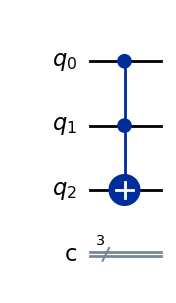

In [ ]:
mcx = MCXGate(num_ctrl_qubits=2)

qc.compose(mcx).draw('mpl')

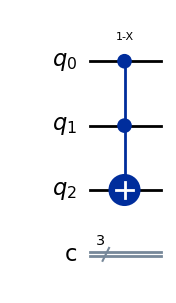

In [ ]:
xgate = XGate()
mcmt = MCMTGate(gate=xgate,num_ctrl_qubits=2, num_target_qubits=1)

qc.compose(mcmt).draw('mpl')